# Ablation study

In [2]:
import pandas as pd
import numpy as np
from collections import defaultdict

# Initialize results with float as default value
results = defaultdict(lambda: defaultdict(float))

# List of tasks
tasks = ['xtreme_r.udpos', 'xnli', 'wikiann']

# Aggregate accuracy across all tasks
for task in tasks:
    df = pd.read_csv(f"summary_xlm-roberta-base_{task}.csv")
    
    for _, row in df.iterrows():
        exp = row['exp']
        # Extract accuracy before the "$\pm$"
        acc_str = row['final_eval_avg_performance'].split("\\scriptsize $\\pm$")[0].strip()
        accuracy = round(float(acc_str), 1)
        results[exp][task] = accuracy

# Now average across the 4 tasks
xlmr_averaged_results = {}
for exp, task_scores in results.items():
    if not 'abla' in exp:
        continue
    if len(task_scores) == len(tasks):  # only include if all tasks are present
        avg = round(sum(task_scores.values()) / len(tasks), 1)
        xlmr_averaged_results[exp] = {
            'avg': avg,
            **task_scores  # includes individual task scores
        }

results = defaultdict(lambda: defaultdict(float))
# Aggregate accuracy across all tasks
for task in tasks:
    df = pd.read_csv(f"summary_bert-base-multilingual-cased_{task}.csv")
    
    for _, row in df.iterrows():
        exp = row['exp']
        # Extract accuracy before the "$\pm$"
        acc_str = row['final_eval_avg_performance'].split("\\scriptsize $\\pm$")[0].strip()
        accuracy = round(float(acc_str), 1)
        results[exp][task] = accuracy

# Now average across the 4 tasks
mbert_averaged_results = {}
for exp, task_scores in results.items():
    if not 'abla' in exp:
        continue
    if len(task_scores) == len(tasks):  # only include if all tasks are present
        avg = round(sum(task_scores.values()) / len(tasks), 1)
        mbert_averaged_results[exp] = {
            'avg': avg,
            **task_scores  # includes individual task scores
        }

In [ ]:
# XLM-R
for exp_name, exp_val in xlmr_averaged_results.items():
    if ('abla' not in exp_name or ('family' in exp_name or 'script' in exp_name)) and exp_name not in ['baseline', 'xt_afri']:
        continue
    print(exp_name)
    print(exp_val['xtreme_r.udpos'], '&', exp_val['xnli'], '&', exp_val['wikiann'], '&', exp_val['avg'])
print('\n\n\nbest_appoach')
best_exp = max(xlmr_averaged_results.items(), key=lambda x: x[1]['avg'])
best_exp_name = best_exp[0]
best_exp_val = best_exp[1]

## Print the result
print("Best experiment:", best_exp_name)
print("Scores:")
print(best_exp_val['xtreme_r.udpos'], '&', best_exp_val['xnli'], '&', best_exp_val['wikiann'], '&', best_exp_val['avg'])

# mBERT
for exp_name, exp_val in mbert_averaged_results.items():
    if ('abla' not in exp_name or ('family' in exp_name or 'script' in exp_name)) and exp_name not in ['baseline', 'xt_afri']:
        continue
    print(exp_name)
    print(exp_val['xtreme_r.udpos'], '&', exp_val['xnli'], '&', exp_val['wikiann'], '&', exp_val['avg'])

print('\n\n\nbest_appoach')
best_exp = max(mbert_averaged_results.items(), key=lambda x: x[1]['avg'])
best_exp_name = best_exp[0]
best_exp_val = best_exp[1]

# Print the result
print("Best experiment:", best_exp_name)
print("Scores:")
print(best_exp_val['xtreme_r.udpos'], '&', best_exp_val['xnli'], '&', best_exp_val['wikiann'], '&', best_exp_val['avg'])

In [7]:
import re

abla_families = defaultdict(list)
SORT_COLUMNS = sorted(set(xlmr_averaged_results.keys()).intersection(set(mbert_averaged_results.keys())))

for name in SORT_COLUMNS:
    if 'abla' not in name or 'family' in name or 'script' in name:
        continue
    # elif name in ["xt_afri", "xt_only", "afri_only"]:
    #     families['realignment_baseline'].append(name)
    else:
        # Remove trailing underscore + number
        match = re.match(r"(.+?)(?:_\d+)?$", name)
        if match:
            family = match.group(1)
            abla_families[family].append(name)

# Optional: print the result nicely
for fam, members in abla_families.items():
    print(f"{fam}: {members}")

abla_most_uriel_joshi2: ['abla_most_uriel_joshi2']
abla_most_uriel_joshi3: ['abla_most_uriel_joshi3']
abla_most_uriel_joshi35: ['abla_most_uriel_joshi35']
abla_most_uriel_joshi45: ['abla_most_uriel_joshi45']
abla_most_uriel_seen_mbert: ['abla_most_uriel_seen_mbert']
abla_most_uriel_seen_xlmr: ['abla_most_uriel_seen_xlmr']
abla_most_uriel_unseen_mbert: ['abla_most_uriel_unseen_mbert']
abla_most_uriel_unseen_xlmr: ['abla_most_uriel_unseen_xlmr']
abla_random_joshi2: ['abla_random_joshi2']
abla_random_joshi3: ['abla_random_joshi3']
abla_random_joshi35: ['abla_random_joshi35']
abla_random_joshi45: ['abla_random_joshi45']
abla_random_seen_mbert: ['abla_random_seen_mbert']
abla_random_seen_xlmr: ['abla_random_seen_xlmr']
abla_random_unseen_mbert: ['abla_random_unseen_mbert']
abla_random_unseen_xlmr: ['abla_random_unseen_xlmr']


['abla_most_family_joshi2', 'abla_most_family_joshi3', 'abla_most_family_joshi35', 'abla_most_family_seen_mbert', 'abla_most_family_seen_xlmr', 'abla_most_family_unseen_mbert', 'abla_most_family_unseen_xlmr', 'abla_most_script_joshi2', 'abla_most_script_joshi3', 'abla_most_script_joshi35', 'abla_most_script_joshi45', 'abla_most_script_seen_mbert', 'abla_most_script_seen_xlmr', 'abla_most_uriel_joshi2', 'abla_most_uriel_joshi3', 'abla_most_uriel_joshi35', 'abla_most_uriel_joshi45', 'abla_most_uriel_seen_mbert', 'abla_most_uriel_seen_xlmr', 'abla_most_uriel_unseen_mbert', 'abla_most_uriel_unseen_xlmr', 'abla_random_joshi2', 'abla_random_joshi3', 'abla_random_joshi35', 'abla_random_joshi45', 'abla_random_seen_mbert', 'abla_random_seen_xlmr', 'abla_random_unseen_mbert', 'abla_random_unseen_xlmr', 'xt_afri']


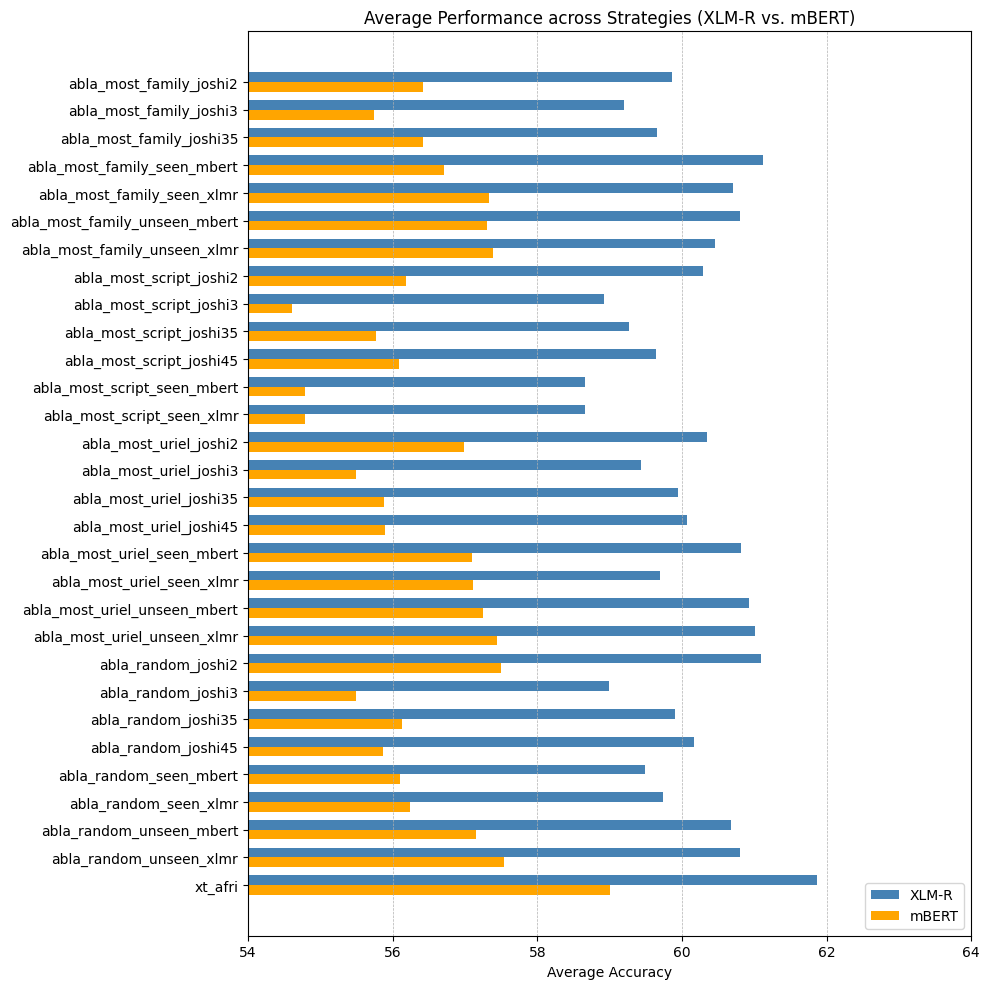

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Extract values in the defined order
abla_exp = [exp for exp in sorted(xlmr_averaged_results.keys()) if exp.startswith("abla") or exp.endswith("afri")]
SORT_COLUMNS = abla_exp
# SORT_COLUMNS = sorted(set(xlmr_averaged_results.keys()).intersection(set(mbert_averaged_results.keys())))
print(SORT_COLUMNS)
xlmr_scores = [xlmr_averaged_results[k] for k in SORT_COLUMNS]
mbert_scores = [mbert_averaged_results[k] for k in SORT_COLUMNS]

# Plot setup
y = np.arange(len(SORT_COLUMNS))
bar_height = 0.35

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(y - bar_height/2, xlmr_scores, height=bar_height, label='XLM-R', color='steelblue')
ax.barh(y + bar_height/2, mbert_scores, height=bar_height, label='mBERT', color='orange')

# Labels and formatting
ax.set_yticks(y)
# ax.set_yticklabels(LABELS)
ax.set_yticklabels(SORT_COLUMNS)
ax.invert_yaxis()
ax.set_xlabel("Average Accuracy")
ax.set_title("Average Performance across Strategies (XLM-R vs. mBERT)")
ax.set_xlim(54, 64)
# ax.set_xlim(30, 45)
ax.legend(loc="lower right")
plt.tight_layout()
plt.grid(axis='x', linestyle='--', linewidth=0.5)
plt.show()

# Bar plot

In [5]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

# Initialize results with float as default value
results = defaultdict(list)

# List of tasks
#, 'xquad'
tasks = ['xtreme_r.udpos', 'xnli', 'wikiann']
# tasks = ['americasnli', 'masakha_unseen_ner', 'masakha_unseen_pos']
# tasks = ['americasnli']

# Aggregate accuracy across all tasks
for task in tasks:
    df = pd.read_csv(f"summary_xlm-roberta-base_{task}.csv")
    
    for _, row in df.iterrows():
        exp = row['exp']
        # Extract accuracy before the "$\pm$"
        acc_str = row['final_eval_avg_performance'].split("\\scriptsize $\\pm$")[0].strip()
        accuracy = float(acc_str)
        results[exp].append(accuracy)

# Now average across the 4 tasks
xlmr_averaged_results = {k: sum(v) / len(tasks) for k, v in results.items() if len(v) == len(tasks)}

results = defaultdict(list)
# Aggregate accuracy across all tasks
for task in tasks:
    df = pd.read_csv(f"summary_bert-base-multilingual-cased_{task}.csv")
    
    for _, row in df.iterrows():
        exp = row['exp']
        # Extract accuracy before the "$\pm$"
        acc_str = row['final_eval_avg_performance'].split("\\scriptsize $\\pm$")[0].strip()
        accuracy = float(acc_str)
        results[exp].append(accuracy)

# Now average across the 4 tasks
mbert_averaged_results = {k: sum(v) / len(tasks) for k, v in results.items() if len(v) == len(tasks)}

In [6]:
import re

families = defaultdict(list)
SORT_COLUMNS = sorted(set(xlmr_averaged_results.keys()).intersection(set(mbert_averaged_results.keys())))

for name in SORT_COLUMNS:
    if 'abla' in name:
        continue
    # elif name in ["xt_afri", "xt_only", "afri_only"]:
    #     families['realignment_baseline'].append(name)
    else:
        # Remove trailing underscore + number
        match = re.match(r"(.+?)(?:_\d+)?$", name)
        if match:
            family = match.group(1)
            families[family].append(name)

# Optional: print the result nicely
for fam, members in families.items():
    print(f"{fam}: {members}")

afri_only: ['afri_only']
baseline: ['baseline']
least_family_en: ['least_family_en_10', 'least_family_en_20', 'least_family_en_5']
least_same_script: ['least_same_script_10', 'least_same_script_20', 'least_same_script_5']
least_uriel_en: ['least_uriel_en_10', 'least_uriel_en_20', 'least_uriel_en_40', 'least_uriel_en_5']
most_distinct_script: ['most_distinct_script_10', 'most_distinct_script_18', 'most_distinct_script_5']
most_family_en: ['most_family_en_10', 'most_family_en_20', 'most_family_en_25', 'most_family_en_5']
most_same_script: ['most_same_script_10', 'most_same_script_20', 'most_same_script_41', 'most_same_script_5']
most_uriel_en: ['most_uriel_en_10', 'most_uriel_en_20', 'most_uriel_en_40', 'most_uriel_en_5']
random_langs_with_seed: ['random_langs_with_seed_10', 'random_langs_with_seed_20', 'random_langs_with_seed_40', 'random_langs_with_seed_5']
xt_afri: ['xt_afri']
xt_only: ['xt_only']


## Main Exps

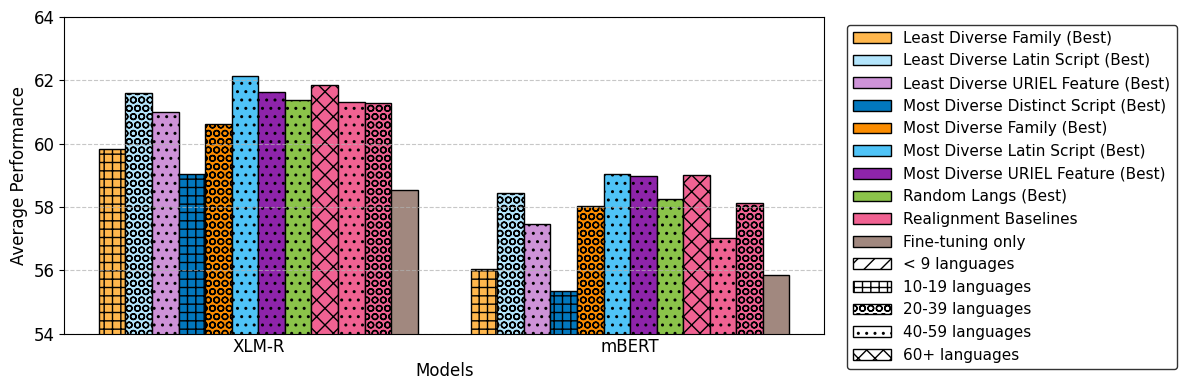

In [8]:
import matplotlib.patches as mpatches

colors = [
    "#FFB74D",  # light orange - Least Diverse Family
    "#B3E5FC",  # light sky blue - Lease Diverse Same Script
    "#CE93D8",  # light lavender-purple - Least Diverse URIEL
    "#0277BD",  # even deeper blue - Most Diverse Distinct Script
    "#FB8C00",  # deep orange - Most Diverse Family
    "#4FC3F7",  # medium sky blue - Most Diverse Same Script
    "#8E24AA",  # deep purple - Most Diverse URIEL Feature
    "#8BC34A",  # light green - Random
    "#17BECF",  # cyan
    "#BCBD22",  # olive
    "#F06292",  # pink
    "#A1887F",  # taupe/brown
]


hatch_patterns = ['//', '++', 'OO', '..', 'xx']

labels = {
    'xt_afri': "Baseline (65 langs)",
    'xt_only': "Baseline (47 langs)",
    'afri_only': "Baseline (21 langs)",
    'baseline': "Fine-tuning only"
}

def beautify_exp_name(exp_name: str, is_best=True):
    if exp_name in baseline:
        return labels[exp_name]
    if "_en" in exp_name or "_with_seed" in exp_name:
        exp_name = exp_name.replace("_en", "").replace("_with_seed", "")
    exp_name = exp_name.replace("_", " ").title()
    if "Most" or "Least" in exp_name:
        exp_name = exp_name.replace("Most", "Most Diverse")
        exp_name = exp_name.replace("Least", "Least Diverse")
    if "Uriel" in exp_name:
        exp_name = exp_name.replace("Uriel", "URIEL Feature")
    if "Same" in exp_name:
        exp_name = exp_name.replace("Same", "Latin")
    if is_best:
        exp_name += " (Best)"
    return exp_name


# 3. --- Plot Generation ---
fig, ax = plt.subplots(figsize=(12, 4))

bar_width = 1.0
group_gap = 2  # The space between the XLM-R and mBERT groups

# Define positions for the bars
baseline = ["xt_afri", "xt_only", "afri_only", "baseline"]
main_families = [family for family in sorted(families.keys()) if not (family.startswith("abla") or family in baseline)]
main_families = sorted(main_families) + baseline
n_bars = len(main_families)
xlmr_x_positions = np.arange(n_bars)
mbert_x_positions = np.arange(n_bars) + n_bars + group_gap

xlmr_best_mem = dict()
# --- Plot XLM-R bars ---
for i, exp_fam in enumerate(main_families):
    exp_candidates = [(exp_mem, xlmr_averaged_results[exp_mem]) for exp_mem in families[exp_fam]]
    exp_mem_best = max(exp_candidates, key=lambda x: x[1])
    xlmr_best_mem[exp_mem_best[0]] = exp_fam
    if exp_mem_best[0] in ["xt_afri", "xt_only", "afri_only", "baseline"]:
        if exp_mem_best[0] == "xt_afri":
            hatch = hatch_patterns[4]
        elif exp_mem_best[0] == "xt_only":
            hatch = hatch_patterns[3]
        elif exp_mem_best[0] == "afri_only":
            hatch = hatch_patterns[2]
        else:
            hatch = ''
    else:
        exp_mem_size = int(exp_mem_best[0].split("_")[-1])
        if exp_mem_size < 9:
            hatch = hatch_patterns[0]
        elif exp_mem_size < 19:
            hatch = hatch_patterns[1]
        elif exp_mem_size <39:
            hatch = hatch_patterns[2]
        elif exp_mem_size <59:
            hatch = hatch_patterns[3]
        else:
            hatch = hatch_patterns[4]

    color = colors[i] if exp_mem_best[0] not in ["xt_afri", "xt_only", "afri_only"] else colors[-2]
    ax.bar(
        xlmr_x_positions[i],
        exp_mem_best[1],
        width=bar_width,
        color=color,
        hatch=hatch,
        edgecolor='black',
        capsize=4  # Error bar cap size
    )

mbert_best_mem = dict()
# --- Plot mBERT bars ---
for i, exp_fam in enumerate(main_families):
    exp_candidates = [(exp_mem, mbert_averaged_results[exp_mem]) for exp_mem in families[exp_fam]]
    exp_mem_best = max(exp_candidates, key=lambda x: x[1])
    mbert_best_mem[exp_mem_best[0]] = exp_fam
    if exp_mem_best[0] in ["xt_afri", "xt_only", "afri_only", "baseline"]:
        if exp_mem_best[0] == "xt_afri":
            hatch = hatch_patterns[4]
        elif exp_mem_best[0] == "xt_only":
            hatch = hatch_patterns[3]
        elif exp_mem_best[0] == "afri_only":
            hatch = hatch_patterns[2]
        else:
            hatch = ''
    else:
        exp_mem_size = int(exp_mem_best[0].split("_")[-1])
        if exp_mem_size < 9:
            hatch = hatch_patterns[0]
        elif exp_mem_size < 19:
            hatch = hatch_patterns[1]
        elif exp_mem_size <39:
            hatch = hatch_patterns[2]
        elif exp_mem_size <59:
            hatch = hatch_patterns[3]
        else:
            hatch = hatch_patterns[4]

    color = colors[i] if exp_mem_best[0] not in ["xt_afri", "xt_only", "afri_only"] else colors[-2]
    ax.bar(
        mbert_x_positions[i],
        exp_mem_best[1],
        width=bar_width,
        color=color,
        hatch=hatch,
        edgecolor='black',
        capsize=4  # Error bar cap size
    )

# 4. --- Legend Creation ---
# Create custom legend handles (patches) to display on top
legend_handles = []
seen_labels = set()
for i, exp_fam in enumerate(main_families):
    if exp_fam in ["xt_afri", "xt_only", "afri_only"]:
        label = "Realignment Baselines"
        color = colors[-2]
        
        # Add only once
        if label not in seen_labels:
            handle = mpatches.Patch(
                facecolor=color,
                edgecolor='black',
                label=label
            )
            legend_handles.append(handle)
            seen_labels.add(label)
    else:
        label = beautify_exp_name(exp_fam)
        color = colors[i]
        
        # Avoid duplicate labels if any
        if label not in seen_labels:
            handle = mpatches.Patch(
                facecolor=color,
                edgecolor='black',
                label=label
            )
            legend_handles.append(handle)
            seen_labels.add(label)
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_patterns[0], label='< 9 languages'))
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_patterns[1], label='10-19 languages'))
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_patterns[2], label='20-39 languages'))
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_patterns[3], label='40-59 languages'))
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_patterns[4], label='60+ languages'))

ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    ncol=1,
    fontsize=11,
    frameon=True,
    edgecolor='black',
    handlelength=2.5,
)

# 5. --- Final Styling ---
# Set Y-axis label and grid
ax.set_ylabel('Average Performance', fontsize=12) # Changed label to be more generic
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Set X-axis labels for the main groups (XLM-R and mBERT)
group_centers = [np.mean(xlmr_x_positions), np.mean(mbert_x_positions)]
ax.set_xticks(group_centers)
ax.set_xticklabels(['XLM-R', 'mBERT'], fontsize=12)
ax.set_xlabel('Models', fontsize=12) # Changed label to be more generic


# Remove the small tick marks on the x-axis for a cleaner look
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', labelsize=12)


# Set Y-axis limits. Adjust if necessary based on your actual data range.
ax.set_ylim(54, 64)

# Adjust layout to prevent the legend from being cut off
plt.tight_layout() # rect=[left, bottom, right, top]

# Show the plot
# plt.show()
plt.savefig('main_exps_plot.png', dpi=300)


## AmericasNLI

In [ ]:
import pandas as pd
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

# Initialize results with float as default value
results = defaultdict(list)

# List of tasks
#, 'xquad'
# tasks = ['xtreme_r.udpos', 'xnli', 'wikiann']
# tasks = ['americasnli', 'masakha_unseen_ner', 'masakha_unseen_pos']
tasks = ['americasnli']

# Aggregate accuracy across all tasks
for task in tasks:
    df = pd.read_csv(f"summary_xlm-roberta-base_{task}.csv")
    
    for _, row in df.iterrows():
        exp = row['exp']
        # Extract accuracy before the "$\pm$"
        acc_str = row['final_eval_avg_performance'].split("\\scriptsize $\\pm$")[0].strip()
        accuracy = float(acc_str)
        results[exp].append(accuracy)

# Now average across the 4 tasks
xlmr_averaged_results = {k: sum(v) / len(tasks) for k, v in results.items() if len(v) == len(tasks)}

results = defaultdict(list)
# Aggregate accuracy across all tasks
for task in tasks:
    df = pd.read_csv(f"summary_bert-base-multilingual-cased_{task}.csv")
    
    for _, row in df.iterrows():
        exp = row['exp']
        # Extract accuracy before the "$\pm$"
        acc_str = row['final_eval_avg_performance'].split("\\scriptsize $\\pm$")[0].strip()
        accuracy = float(acc_str)
        results[exp].append(accuracy)

# Now average across the 4 tasks
mbert_averaged_results = {k: sum(v) / len(tasks) for k, v in results.items() if len(v) == len(tasks)}

In [ ]:
# Labels for display
labels = {
    'xt_afri': "Baseline (65 langs)",
    'xt_only': "Baseline (47 langs)",
    'afri_only': "Baseline (21 langs)",
    'baseline': "Fine-tuning only"
}

baseline = ["xt_afri", "xt_only", "afri_only", "baseline"]
main_families = [family for family in sorted(families.keys()) if not (family.startswith("abla") or family in baseline)]
main_families = sorted(main_families) + baseline

# Order for plotting
xlmr_best_mem = dict()
# --- Plot XLM-R bars ---
for i, exp_fam in enumerate(main_families):
    exp_candidates = [(exp_mem, xlmr_averaged_results[exp_mem]) for exp_mem in families[exp_fam]]
    exp_mem_best = max(exp_candidates, key=lambda x: x[1])
    xlmr_best_mem[exp_mem_best[0]] = exp_fam

mbert_best_mem = dict()
# --- Plot mBERT bars ---
for i, exp_fam in enumerate(main_families):
    exp_candidates = [(exp_mem, mbert_averaged_results[exp_mem]) for exp_mem in families[exp_fam]]
    exp_mem_best = max(exp_candidates, key=lambda x: x[1])
    mbert_best_mem[exp_mem_best[0]] = exp_fam
plot_keys_xlmr = [
    beautify_exp_name(fam_best) for fam_best in xlmr_best_mem.values() 
]

plot_keys_mbert = [
    beautify_exp_name(fam_best) for fam_best in mbert_best_mem.values() 
]


# Plot setup
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)
colors = [
    "#FFB74D",  # light orange - Least Diverse Family
    "#B3E5FC",  # light sky blue - Lease Diverse Same Script
    "#CE93D8",  # light lavender-purple - Least Diverse URIEL
    "#0277BD",  # even deeper blue - Most Diverse Distinct Script
    "#FB8C00",  # deep orange - Most Diverse Family
    "#4FC3F7",  # medium sky blue - Most Diverse Same Script
    "#8E24AA",  # deep purple - Most Diverse URIEL Feature
    "#8BC34A",  # light green - Random
    "#F06292",  # cyan
    "#F06292",  # olive
    "#F06292",  # pink
    "#A1887F",  # taupe/brown
]

y_labels = plot_keys_xlmr
xlmr_vals = [xlmr_averaged_results[k] for k in xlmr_best_mem.keys()]
mbert_vals = [mbert_averaged_results[k] for k in mbert_best_mem.keys()]
y_pos = range(len(main_families))

# XLM-R plot
bars1 = ax1.barh(y_pos, xlmr_vals[::-1], color=colors[::-1])
ax1.set_xlabel("XLM-R OOD Performance", fontsize=12)
ax1.set_xlim(38, 46)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(y_labels[::-1], fontsize=12)
ax1.tick_params(axis='x', labelsize=12) # Increase x-tick label font size
ax1.grid(axis='y', linestyle='-', alpha=0.5, zorder=0)

for i, key in list(enumerate(xlmr_best_mem.keys())):
    i = len(plot_keys_xlmr) - i - 1
    if key in ["xt_afri", "xt_only", "afri_only", "baseline"]:
        if key == "xt_afri":
            hatch = hatch_patterns[4]
        elif key == "xt_only":
            hatch = hatch_patterns[3]
        elif key == "afri_only":
            hatch = hatch_patterns[2]
        else:
            hatch = ''
    else:
        exp_mem_size = int(key.split("_")[-1])
        if exp_mem_size < 9:
            hatch = hatch_patterns[0]
        elif exp_mem_size < 19:
            hatch = hatch_patterns[1]
        elif exp_mem_size <39:
            hatch = hatch_patterns[2]
        elif exp_mem_size <59:
            hatch = hatch_patterns[3]
        else:
            hatch = hatch_patterns[4]
    bars1[i].set_hatch(hatch) # Apply a hatching pattern (e.g., diagonal lines)
    bars1[i].set_edgecolor('black') # Add a black border for more definition
    bars1[i].set_linewidth(0.8) # Adjust border thickness

baseline_ft_xlmr = xlmr_averaged_results['baseline']

ax1.axvline(x=baseline_ft_xlmr, color='violet', linestyle='--', linewidth=1, zorder=0)

# mBERT plot
bars2 = ax2.barh(y_pos, mbert_vals[::-1], color=colors[::-1])
ax2.set_xlabel("mBERT OOD Performance", fontsize=12)
ax2.set_xlim(38, 46)
ax2.tick_params(axis='x', labelsize=12) # Increase x-tick label font size
ax2.grid(axis='y', linestyle='-', alpha=0.5, zorder=0)

for i, key in list(enumerate(mbert_best_mem.keys())):
    i = len(plot_keys_xlmr) - i - 1
    if key in ["xt_afri", "xt_only", "afri_only", "baseline"]:
        if key == "xt_afri":
            hatch = hatch_patterns[4]
        elif key == "xt_only":
            hatch = hatch_patterns[3]
        elif key == "afri_only":
            hatch = hatch_patterns[2]
        else:
            hatch = ''
    else:
        exp_mem_size = int(key.split("_")[-1])
        if exp_mem_size < 9:
            hatch = hatch_patterns[0]
        elif exp_mem_size < 19:
            hatch = hatch_patterns[1]
        elif exp_mem_size <39:
            hatch = hatch_patterns[2]
        elif exp_mem_size <59:
            hatch = hatch_patterns[3]
        else:
            hatch = hatch_patterns[4]
    bars2[i].set_hatch(hatch) # Apply a hatching pattern (e.g., diagonal lines)
    bars2[i].set_edgecolor('black') # Add a black border for more definition
    bars2[i].set_linewidth(0.8) # Adjust border thickness

# Add vertical grid lines for baselines in mBERT plot
baseline_ft_mbert = mbert_averaged_results['baseline']

ax2.axvline(x=baseline_ft_mbert, color='violet', linestyle='--', linewidth=1, zorder=0)

legend_handles=[]
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_patterns[0], label='< 9 languages'))
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_patterns[1], label='10-19 languages'))
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_patterns[2], label='20-39 languages'))
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_patterns[3], label='40-59 languages'))
legend_handles.append(mpatches.Patch(facecolor='white', edgecolor='black', hatch=hatch_patterns[4], label='60+ languages'))
fig.legend(
    handles=legend_handles,
    bbox_to_anchor=(1, 1),
    loc='upper left',
    ncol=1,
    fontsize=11,
    frameon=True,
    edgecolor='black',
    handlelength=2.5,
    title="Languages set size",
)

# plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.tight_layout()
plt.savefig('americasnli_plot.png', dpi=300, bbox_inches='tight')
# plt.show()

# Spider plot

In [9]:
print("XLM-R Best:\n", xlmr_best_mem)
print("\n\nmBERT Best:\n", mbert_best_mem)

XLM-R Best:
 {'least_family_en_10': 'least_family_en', 'least_same_script_20': 'least_same_script', 'least_uriel_en_40': 'least_uriel_en', 'most_distinct_script_10': 'most_distinct_script', 'most_family_en_25': 'most_family_en', 'most_same_script_41': 'most_same_script', 'most_uriel_en_40': 'most_uriel_en', 'random_langs_with_seed_40': 'random_langs_with_seed', 'xt_afri': 'xt_afri', 'xt_only': 'xt_only', 'afri_only': 'afri_only', 'baseline': 'baseline'}


mBERT Best:
 {'least_family_en_10': 'least_family_en', 'least_same_script_20': 'least_same_script', 'least_uriel_en_40': 'least_uriel_en', 'most_distinct_script_18': 'most_distinct_script', 'most_family_en_25': 'most_family_en', 'most_same_script_41': 'most_same_script', 'most_uriel_en_40': 'most_uriel_en', 'random_langs_with_seed_40': 'random_langs_with_seed', 'xt_afri': 'xt_afri', 'xt_only': 'xt_only', 'afri_only': 'afri_only', 'baseline': 'baseline'}


In [10]:
from langcodes import *

with_en=True

# Constants
MASAKHA_DICT = {
    "Masakha": ['bam', 'ewe', 'fon', 'hau', 'ibo', 'kin', 'lug', 'luo', 'mos', 'nya', 'sna', 'swa', 'tsn', 'twi', 'wol', 'xho', 'yor', 'zul'],
}
MASAKHA_UNSEEN = ['bbj', 'pcm']
#-----------NLI-----------
NLI_DICT = {
    "XNLI": ['ar', 'bg', 'de', 'el', 'es', 'fr', 'hi', 'ru', 'sw', 'th', 'tr', 'ur', 'vi', 'zh'],
    "AfriXNLI": ['amh', 'ewe', 'hau', 'ibo', 'kin', 'lin', 'lug', 'orm', 'sna', 'sot', 'swa', 'twi', 'wol', 'xho', 'yor', 'zul'],
    "AmericasNLI": ['aym', 'bzd', 'cni', 'gn', 'hch', 'nah', 'oto', 'quy', 'shp', 'tar']
}
NLI_LANGS = [
    lang for lang in NLI_DICT['XNLI'] 
    if Language.get(lang).to_alpha3() not in NLI_DICT['AfriXNLI'] + ["mya", "ind"]
    ] + NLI_DICT['AfriXNLI'] + ["mya", "ind"]

#-----------POS-----------
POS_DICT = {
    "UDPOS": ['af', 'ar', 'bg', 'de', 'el', 'es', 'et', 'eu', 'fa', 'fi', 'fr', 'he', 'hi', 'hu', 'id', 'it', 'ja', 'kk', 'ko', 'lt', 'mr', 'nl', 'pl', 'pt', 'ro', 'ru', 'ta', 'te', 'th', 'tl', 'tr', 'uk', 'ur', 'vi', 'wo', 'yo', 'zh'],
}
POS_LANGS = [
    lang for lang in POS_DICT['UDPOS'] 
    if Language.get(lang).to_alpha3() not in MASAKHA_DICT['Masakha']
    ] + MASAKHA_DICT['Masakha']

#-----------NER-----------
NER_DICT = {
    "Wikiann": ['af', 'ar', 'az', 'bg', 'bn', 'de', 'el', 'es', 'et', 'eu', 'fa', 'fi', 'fr', 'gu', 'he', 'hi', 'hu', 'id', 'it', 'ja', 'jv', 'ka', 'kk', 'ko', 'lt', 'ml', 'mr', 'ms', 'my', 'nl', 'pa', 'pl', 'pt', 'qu', 'ro', 'ru', 'sw', 'ta', 'te', 'th', 'tl', 'tr', 'uk', 'ur', 'vi', 'yo', 'zh'],
}
NER_LANGS = [
    lang for lang in NER_DICT['Wikiann'] 
    if Language.get(lang).to_alpha3() not in MASAKHA_DICT['Masakha']
    ] + MASAKHA_DICT['Masakha']

#-----------QA-----------
QA_DICT = {
    "XQuAD": ['ar', 'de', 'el', 'es', 'hi', 'ru', 'th', 'tr', 'vi', 'zh']
}
QA_LANGS = [
    lang for lang in QA_DICT['XQuAD'] 
    if Language.get(lang).to_alpha3() != "ind"
    ] + ['ind']
if with_en:
    for langs in POS_LANGS, NER_LANGS, NLI_LANGS, QA_LANGS:
        langs += ['same']

In [11]:
joshi_dict = {}
with open('lang2tax.txt', 'r', encoding='utf-8') as f:
    for line in f:
        language, joshi_class = line.strip().split(',')
        joshi_dict[language] = int(joshi_class)

In [12]:
hrls, mrls, lrls = [], [], []

full_name_langs = {
    lang: Language.get(lang).display_name().lower() for lang in set(NLI_LANGS + NER_LANGS + POS_LANGS)
}
for lang in full_name_langs.keys():
    try:
        full_name = full_name_langs[lang]
        joshi_class = joshi_dict[full_name]
        if joshi_class <= 2:
            lrls.append(lang)
        elif joshi_class <= 4:
            mrls.append(lang)
        else: 
            hrls.append(lang)
    except:
        print(full_name, lang)

punjabi pa
fon fon
unknown language [same] same
ganda lug
filipino tl
mossi mos
southern sotho sot
bangla bn
chinese zh
luo (kenya and tanzania) luo
nyanja nya


In [13]:
hrls.extend(['same', 'zh'])
mrls.extend(['tl', 'bn'])
lrls.extend(['fon', 'sot', 'nya', 'lug', 'luo', 'mos', 'pa'])
hrls = set(hrls)
mrls = set(mrls)
lrls = set(lrls)

In [53]:
import pandas as pd

import os

xlmr_lrl_seen = ['amh', 'xho', 'orm', 'hau', 'swa']
mbert_lrl_seen = ['swa', 'yor']
list_dfs = []
for model in ["xlm-roberta-base", "bert-base-multilingual-cased"]:
    model_df = pd.DataFrame(columns=['exp', 'hrl', 'mrl', 'lrl_seen', 'lrl_unseen'])
    best_mem_dict = xlmr_best_mem if model == "xlm-roberta-base" else mbert_best_mem
    tasks = ['xtreme_r.udpos', 'xnli', 'wikiann']
    for task in tasks:
        df = pd.read_csv(f"summary_{model}_{task}.csv")
        df = df[df['exp'].isin(best_mem_dict.keys())]
        df['exp'] = df['exp'].map(lambda x: best_mem_dict[x])
        df['exp'] = pd.Categorical(df['exp'], categories=best_mem_dict.values(), ordered=True)

        task_dict = {
            "xtreme_r.udpos": (POS_LANGS, "final_eval_{}_accuracy"),
            "xnli": (NLI_LANGS, "final_eval_{}_accuracy"),
            "wikiann": (NER_LANGS, "final_eval_{}_f1"),
        }
        eval_langs, col_template = task_dict[task]
        seen_langs = xlmr_lrl_seen if model == "xlm-roberta-base" else mbert_lrl_seen

        # Build columns
        hrl_cols = [col_template.format(lang) for lang in hrls if lang in eval_langs]
        mrl_cols = [col_template.format(lang) for lang in mrls if lang in eval_langs]
        lrl_seen_cols = [col_template.format(lang) for lang in lrls if lang in eval_langs and lang in seen_langs]
        lrl_unseen_cols = [col_template.format(lang) for lang in lrls if lang in eval_langs and lang not in seen_langs]

        # Clean and convert values
        for col in hrl_cols + mrl_cols + lrl_seen_cols + lrl_unseen_cols:
            df[col] = df[col].str.split(' ').str[0].str.strip().astype(float)

        # Initialize or accumulate to model_df
        if model_df.empty:
            model_df['exp'] = df['exp']
            model_df['hrl'] = df[hrl_cols].mean(axis=1)
            model_df['mrl'] = df[mrl_cols].mean(axis=1)
            model_df['lrl_seen'] = df[lrl_seen_cols].mean(axis=1)
            model_df['lrl_unseen'] = df[lrl_unseen_cols].mean(axis=1)
        else:
            model_df['hrl'] += df[hrl_cols].mean(axis=1)
            model_df['mrl'] += df[mrl_cols].mean(axis=1)
            model_df['lrl_seen'] += df[lrl_seen_cols].mean(axis=1)
            model_df['lrl_unseen'] += df[lrl_unseen_cols].mean(axis=1)
    model_df['hrl'] /= len(tasks)
    model_df['mrl'] /= len(tasks)
    model_df['lrl_seen'] /= len(tasks)
    model_df['lrl_unseen'] /= len(tasks)
    list_dfs.append(model_df.reset_index(drop=True))

merged_df = []
for i in range(len(list_dfs)):
    if i == 0:
        merged_df.append(list_dfs[i])
    else:
        merged_df.append(list_dfs[i][['hrl', 'mrl', 'lrl_seen', 'lrl_unseen']])
merged_df = pd.concat(merged_df, axis=1)

merged_df['exp'] = merged_df['exp'].apply(lambda x: beautify_exp_name(x))
merged_df['mean'] = merged_df.iloc[:, 1:].mean(axis=1)

merged_df

,exp,hrl,mrl,lrl_seen,lrl_unseen,hrl,mrl,lrl_seen,lrl_unseen,mean
0,Baseline (21 langs),71.634921,72.161111,51.054889,45.314020,69.255317,67.403062,44.161667,44.845696,58.228835
1,Fine-tuning only,72.508254,73.222309,48.289333,36.372696,70.795873,69.686012,43.611667,35.713319,56.274933
2,Least Diverse Family (Best),71.971111,72.794556,48.905111,40.570613,69.888413,69.085815,42.423333,37.105985,56.593117
3,Least Diverse Latin Script (Best),71.754286,72.565494,50.426889,45.454412,69.808730,68.768519,44.441667,43.587904,58.350987
4,Least Diverse URIEL Feature (Best),71.731270,72.696617,50.178667,43.845261,70.195873,69.007568,41.013333,41.212304,57.485112
5,Most Diverse Distinct Script (Best),71.618968,72.478420,48.769111,38.870131,70.243571,69.087741,42.568333,35.337837,56.121764
6,Most Diverse Family (Best),71.998651,72.692877,50.374889,42.562214,70.433889,69.031309,42.551667,42.374600,57.752512
7,Most Diverse Latin Script (Best),71.911429,72.500938,51.289556,46.903954,69.506984,68.767827,43.443333,45.445474,58.721187
8,Most Diverse URIEL Feature (Best),71.641190,72.568593,50.410889,45.629379,69.972302,68.958198,44.993333,44.703674,58.609695
9,Random Langs (Best),71.696667,72.669407,50.723333,44.756462,69.728333,69.133321,42.451667,43.009259,58.021056


In [36]:
import pandas as pd

import os

SORT_COLUMNS = sorted(set(list(all_best_mem.keys())))
xlmr_lrl_seen = ['amh', 'xho', 'orm', 'hau', 'swa']
mbert_lrl_seen = ['swa', 'yor']
list_dfs = []
for model in ["xlm-roberta-base", "bert-base-multilingual-cased"]:
    model_df = pd.DataFrame(columns=['exp', 'hrl', 'mrl', 'lrl_seen', 'lrl_unseen'])
    tasks = ['xtreme_r.udpos', 'xnli', 'wikiann']
    for task in tasks:
        df = pd.read_csv(f"summary_{model}_{task}.csv")
        df = df[df['exp'].isin(SORT_COLUMNS)]
        df['exp'] = pd.Categorical(df['exp'], categories=SORT_COLUMNS, ordered=True)

        task_dict = {
            "xtreme_r.udpos": (POS_LANGS, "final_eval_{}_accuracy"),
            "xnli": (NLI_LANGS, "final_eval_{}_accuracy"),
            "wikiann": (NER_LANGS, "final_eval_{}_f1"),
        }
        eval_langs, col_template = task_dict[task]
        seen_langs = xlmr_lrl_seen if model == "xlm-roberta-base" else mbert_lrl_seen

        # Build columns
        hrl_cols = [col_template.format(lang) for lang in hrls if lang in eval_langs]
        mrl_cols = [col_template.format(lang) for lang in mrls if lang in eval_langs]
        lrl_seen_cols = [col_template.format(lang) for lang in lrls if lang in eval_langs and lang in seen_langs]
        lrl_unseen_cols = [col_template.format(lang) for lang in lrls if lang in eval_langs and lang not in seen_langs]

        # Clean and convert values
        for col in hrl_cols + mrl_cols + lrl_seen_cols + lrl_unseen_cols:
            df[col] = df[col].str.split(' ').str[0].str.strip().astype(float)

        # Initialize or accumulate to model_df
        if model_df.empty:
            model_df['exp'] = df['exp']
            model_df['hrl'] = df[hrl_cols].mean(axis=1)
            model_df['mrl'] = df[mrl_cols].mean(axis=1)
            model_df['lrl_seen'] = df[lrl_seen_cols].mean(axis=1)
            model_df['lrl_unseen'] = df[lrl_unseen_cols].mean(axis=1)
        else:
            model_df['hrl'] += df[hrl_cols].mean(axis=1)
            model_df['mrl'] += df[mrl_cols].mean(axis=1)
            model_df['lrl_seen'] += df[lrl_seen_cols].mean(axis=1)
            model_df['lrl_unseen'] += df[lrl_unseen_cols].mean(axis=1)
    model_df['hrl'] /= len(tasks)
    model_df['mrl'] /= len(tasks)
    model_df['lrl_seen'] /= len(tasks)
    model_df['lrl_unseen'] /= len(tasks)
    list_dfs.append(model_df)

merged_df = []
for i in range(len(list_dfs)):
    if i == 0:
        merged_df.append(list_dfs[i])
    else:
        merged_df.append(list_dfs[i][['hrl', 'mrl', 'lrl_seen', 'lrl_unseen']])
merged_df = pd.concat(merged_df, axis=1)

merged_df['exp'] = merged_df['exp'].apply(lambda x: beautify_exp_name(all_best_mem[x]))
merged_df['mean'] = merged_df.iloc[:, 1:].mean(axis=1)

merged_df

,exp,hrl,mrl,lrl_seen,lrl_unseen,hrl,mrl,lrl_seen,lrl_unseen,mean
29,Baseline (21 langs),71.634921,72.161111,51.054889,45.314020,69.255317,67.403062,44.161667,44.845696,58.228835
30,Fine-tuning only,72.508254,73.222309,48.289333,36.372696,70.795873,69.686012,43.611667,35.713319,56.274933
31,Least Diverse Family (Best),71.971111,72.794556,48.905111,40.570613,69.888413,69.085815,42.423333,37.105985,56.593117
35,Least Diverse Latin Script (Best),71.754286,72.565494,50.426889,45.454412,69.808730,68.768519,44.441667,43.587904,58.350987
39,Least Diverse URIEL Feature (Best),71.731270,72.696617,50.178667,43.845261,70.195873,69.007568,41.013333,41.212304,57.485112
41,Most Diverse Distinct Script (Best),71.618968,72.478420,48.769111,38.870131,70.476111,68.993753,42.213333,34.438393,55.982277
42,Most Diverse Distinct Script (Best),71.954286,72.621309,48.818222,38.179608,70.243571,69.087741,42.568333,35.337837,56.101363
46,Most Diverse Family (Best),71.998651,72.692877,50.374889,42.562214,70.433889,69.031309,42.551667,42.374600,57.752512
50,Most Diverse Latin Script (Best),71.911429,72.500938,51.289556,46.903954,69.506984,68.767827,43.443333,45.445474,58.721187
54,Most Diverse URIEL Feature (Best),71.641190,72.568593,50.410889,45.629379,69.972302,68.958198,44.993333,44.703674,58.609695


In [54]:
selected_exp = [
    "Most Diverse Family (Best)",
    "Most Diverse Latin Script (Best)",
    "Most Diverse URIEL Feature (Best)",
    "Random Langs (Best)",
    "Fine-tuning only",
    "Baseline (65 langs)",
    "Baseline (47 langs)",
    "Baseline (21 langs)",
]

selected_rows = merged_df[merged_df['exp'].isin(selected_exp)].drop(columns=['mean'])
selected_rows['exp'] = pd.Categorical(selected_rows['exp'], categories=selected_exp, ordered=True)
selected_rows = selected_rows.sort_values('exp')
# selected_rows = selected_rows.reindex(selected_exp)
# data = selected_rows.set_index('exp').apply(list, axis=1).to_dict()
# hrl_data = selected_rows.loc[:, selected_rows.columns.isin(["exp", "hrl", "mrl"])].set_index('exp').apply(list, axis=1).to_dict()
# lrl_data = selected_rows.loc[:, selected_rows.columns.isin(["exp", "lrl_seen", "lrl_unseen"])].set_index('exp').apply(list, axis=1).to_dict()
xlmr_data = selected_rows.iloc[:, :5]
mbert_data = pd.concat([selected_rows[['exp']], selected_rows.iloc[:, 5:]], axis=1)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def get_linestyle(exp_name):
    if "21" in exp_name:
        return "dotted"           # :
    elif "47" in exp_name:
        return (0, (3, 5, 1, 5))  # custom dash-dot-dot
    elif "65" in exp_name:
        return "dashed"           # --
    else:
        return "solid"

#  Labels for radar chart (axes)
# hrl_labels_to_col = {
#     "POS Tagging HRLs (XLM-R)": 1,
#     "POS Tagging MRLs (XLM-R)": 2,  
#     "NLI HRLs (XLM-R)": 3,        
#     "NLI MRLs (XLM-R)": 4, 
#     "NER HRLs (XLM-R)": 5, 
#     "NER MRLs (XLM-R)": 6, 
#     "POS Tagging HRLs (mBERT)": 7,
#     "POS Tagging MRLs (mBERT)": 8,  
#     "NLI HRLs (mBERT)": 9,        
#     "NLI MRLs (mBERT)": 10, 
#     "NER HRLs (mBERT)": 11, 
#     "NER MRLs (mBERT)": 12, 
# }
# rl_labels_to_col = {
#     "HRLs (XLM-R)": 1,
#     "MRLs (XLM-R)": 2,  
#     "LRLs seen pretrained (XLM-R)": 3,        
#     "LRLs unseen pretrained (XLM-R)": 4, 
#     "HRLs (mBERT)": 5,
#     "MRLs (mBERT)": 6,  
#     "LRLs seen pretrained (mBERT)": 7,        
#     "LRLs unseen pretrained (mBERT)": 8, 
# }
# hrl_labels_to_col = {
#     "HRLs (XLM-R)": 1,
#     "MRLs (XLM-R)": 2,  
#     "HRLs (mBERT)": 3,
#     "MRLs (mBERT)": 4,  
# }
lrl_labels_to_col = {
    "LRLs seen pretrained (XLM-R)": 1,
    "LRLs unseen pretrained (XLM-R)": 2,  
    "LRLs seen pretrained (mBERT)": 3,
    "LRLs unseen pretrained (mBERT)": 4,  
}


labels = list(lrl_labels_to_col.keys())

for exp, values in lrl_data.items():
    sorted_values = [values[lrl_labels_to_col[label] - 1] for label in labels]
    lrl_data[exp] = sorted_values

# labels = [label.replace(" ", "\n") for label in labels]
# labels = ["\n".join(label.split("(")) for label in labels]

# Prepare angles
labels += [labels[0]] # close the circle
angles = np.linspace(0, 2 * np.pi, len(labels) - 1, endpoint=False).tolist()
angles += [angles[0]]

# Create plot
fig, ax = plt.subplots(figsize=(6, 4), subplot_kw=dict(polar=True))

# base_labels = [exp.rsplit("(", 1)[0].strip() for exp in data.keys()]
# unique_bases = sorted(set(base_labels))
base_palette = sns.color_palette("tab10", n_colors=len(selected_exp))
# base_color_map = dict(zip(unique_bases, base_palette))
# exp_color_map = {
#     exp: base_color_map[exp.rsplit("(", 1)[0].strip()]
#     for exp in data.keys()
# }

# Marker map
# markers = ['o', 's', 'D', '^', 'v', '*', 'X', 'P', 'h', 'H']
# marker_map = dict(zip(unique_bases, markers[:len(unique_bases)]))
# exp_markers_map = {
#     exp: marker_map[exp.rsplit("(", 1)[0].strip()]
#     for exp in data_dict.keys()
# }

# Plot each model
for i, (name, scores) in enumerate(lrl_data.items()):
    values = scores + [scores[0]]  # close the loop
    if "Fine-tuning" in name:
        ax.plot(angles, values, color='black', linewidth=2.5, label=name)
    else:
        ax.plot(angles, values, label=name, color=base_palette[i], linestyle=get_linestyle(name))
    ax.fill(angles, values, alpha=0.1)

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels[:-1], fontsize=9)

# Increase spacing and wrap labels
# ax.tick_params(pad=24)

# Range and aesthetics
# if not y_min or not y_max:
from itertools import chain

dict_values = lrl_data.values()
flattened = list(chain.from_iterable(dict_values))
y_min, y_max = min(flattened), max(flattened) + 2
ax.set_ylim(y_min, y_max)
# ax.set_rlabel_position(135)
# ax.set_yticklabels([])
# for i, label in enumerate(ax.get_yticklabels()):
#     if i % 3 != 0:
#         label.set_visible(False)
#     else:
#         label.set_fontsize(10)
#         label.set_color("gray")

# ax.legend(
#     loc='lower center',
#     bbox_to_anchor=(0.5, -0.3),  # centered below the plot
#     ncol=2,
#     fontsize=10
# )
ax.legend(
    loc='center left',
    bbox_to_anchor=(1.25, 0.5),
    fontsize=10,
    frameon=False
)

ax.set_theta_offset(np.pi / 8)
ax.yaxis.grid(True, linestyle='--', color='lightgray')
ax.xaxis.grid(True, linestyle='-', color='gray')
fig.subplots_adjust(right=0.65)

plt.savefig(f"radar.png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Heat map

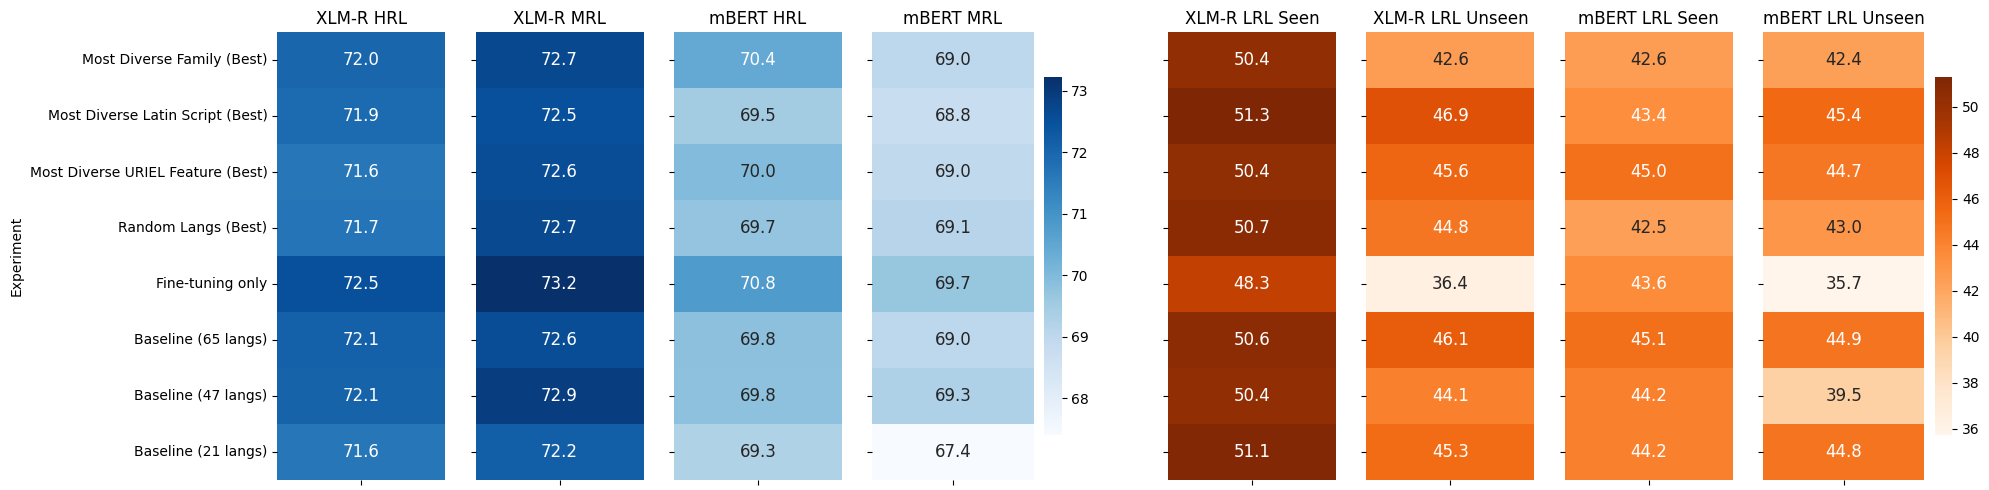

In [59]:
import seaborn as sns

# Calculate global min/max
def get_range(dfs, cols):
    vals = [df[col].tolist() for df in dfs for col in cols]
    flat = [v for sub in vals for v in sub]
    return min(flat), max(flat)

vmin_blue, vmax_blue = get_range([xlmr_data, mbert_data], ['hrl', 'mrl'])
vmin_orange, vmax_orange = get_range([xlmr_data, mbert_data], ['lrl_seen', 'lrl_unseen'])

# Set up subplot: 1 row, 9 cols (8 plots + 1 spacer)
fig, axes = plt.subplots(1, 9, figsize=(20, 5), gridspec_kw={'width_ratios': [1, 1, 1, 1.2, 0.2, 1, 1, 1, 1.2]}, sharey=True)
annot_font_size = 12 
annot_kws = {"fontsize": annot_font_size}

# Plot blue (hrl, mrl) on left 4 plots
blue_info = [
    (xlmr_data, 'hrl', 'XLM-R HRL'),
    (xlmr_data, 'mrl', 'XLM-R MRL'),
    (mbert_data, 'hrl', 'mBERT HRL'),
    (mbert_data, 'mrl', 'mBERT MRL')
]
for i, (df, metric, title) in enumerate(blue_info):
    ax = axes[i]
    pivot = df[['exp', metric]].set_index('exp')
    pivot.columns = [title]
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap='Blues', ax=ax,
                vmin=vmin_blue, vmax=vmax_blue,
                cbar=(i == 3),  # only column 3 shows colorbar
                cbar_kws={'shrink': 0.8, 'location': 'right'} if i == 3 else None,
                annot_kws=annot_kws
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_xticklabels([])
    ax.set_ylabel("Experiment" if i == 0 else "")

# Spacer plot (empty)
axes[4].axis('off')

# Plot orange (lrls) on right 4 plots
orange_info = [
    (xlmr_data, 'lrl_seen', 'XLM-R LRL Seen'),
    (xlmr_data, 'lrl_unseen', 'XLM-R LRL Unseen'),
    (mbert_data, 'lrl_seen', 'mBERT LRL Seen'),
    (mbert_data, 'lrl_unseen', 'mBERT LRL Unseen')
]
for j, (df, metric, title) in enumerate(orange_info):
    ax = axes[j + 5]
    pivot = df[['exp', metric]].set_index('exp')
    pivot.columns = [title]
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap='Oranges', ax=ax,
                vmin=vmin_orange, vmax=vmax_orange,
                cbar=(j == 3),  # only last column shows colorbar
                cbar_kws={'shrink': 0.8, 'location': 'right'} if j == 3 else None,
                annot_kws=annot_kws
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_xticklabels([])
    ax.set_ylabel("")

plt.tight_layout(rect=[0, 0, 1, 1])
plt.savefig('resource_level_plot.png', dpi=300)
plt.show()

# Line Graph

In [674]:
baseline

['xt_afri', 'xt_only', 'afri_only', 'baseline']

In [675]:
import re

families = defaultdict(list)
SORT_COLUMNS = sorted(set(xlmr_averaged_results.keys()).intersection(set(mbert_averaged_results.keys())))

for name in SORT_COLUMNS:
    if 'abla' in name or name in baseline or 'least' in name:
        continue
    else:
        # Remove trailing underscore + number
        match = re.match(r"(.+?)(?:_\d+)?$", name)
        if match:
            family = match.group(1)
            families[family].append(name)
families = {fam: sorted(mem, key=lambda x: int(x.split('_')[-1])) for fam, mem in families.items()}

# families['realignment_baseline'] = ["afri_only", "xt_only", "xt_afri"]

# Optional: print the result nicely
for fam, members in families.items():
    print(f"{fam}: {members}")

most_distinct_script: ['most_distinct_script_5', 'most_distinct_script_10', 'most_distinct_script_18']
most_family_en: ['most_family_en_5', 'most_family_en_10', 'most_family_en_20', 'most_family_en_25']
most_same_script: ['most_same_script_5', 'most_same_script_10', 'most_same_script_20', 'most_same_script_41']
most_uriel_en: ['most_uriel_en_5', 'most_uriel_en_10', 'most_uriel_en_20', 'most_uriel_en_40']
random_langs_with_seed: ['random_langs_with_seed_5', 'random_langs_with_seed_10', 'random_langs_with_seed_20', 'random_langs_with_seed_40']


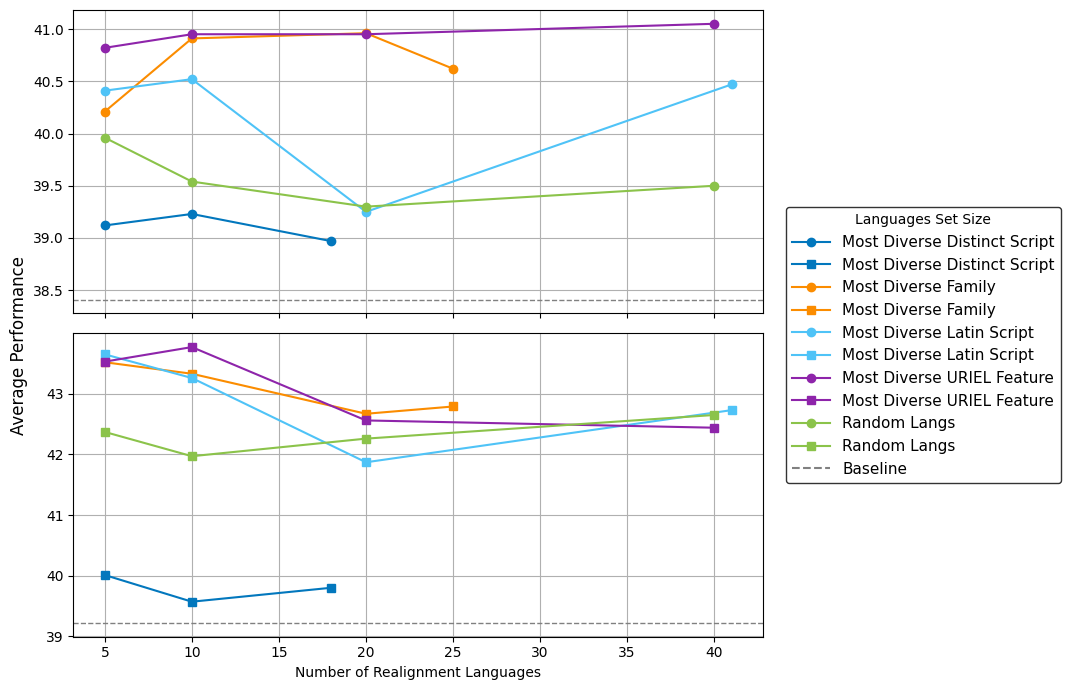

In [676]:
# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

colors = [
    # "#FFB74D",  # light orange - Least Diverse Family
    # "#B3E5FC",  # light sky blue - Lease Diverse Same Script
    # "#CE93D8",  # light lavender-purple - Least Diverse URIEL
    "#0277BD",  # even deeper blue - Most Diverse Distinct Script
    "#FB8C00",  # deep orange - Most Diverse Family
    "#4FC3F7",  # medium sky blue - Most Diverse Same Script
    "#8E24AA",  # deep purple - Most Diverse URIEL Feature
    "#8BC34A",  # light green - Random
    "#F06292",  # pink
    "#A1887F",  # taupe/brown
]
all_handles = []
for idx, (family_name, members) in enumerate(families.items()):
    # members = sorted(members, key=lambda x: int(x.split('_')[-1]))
    if family_name == 'realignment_baseline':
        x = [21, 47, 65]
    else:
        x = [int(name.split('_')[-1]) for name in members]
    y_xlmr = [xlmr_averaged_results[name] for name in members]
    y_mbert = [mbert_averaged_results[name] for name in members]
    
    color = colors[idx % len(colors)]
    label_base = beautify_exp_name(family_name, is_best=False)
    
    h1, = ax1.plot(x, y_xlmr, label=label_base, color=color, marker='o', linestyle='-')
    h2, = ax2.plot(x, y_mbert, label=label_base, color=color, marker='s', linestyle='-')
    all_handles.extend([h1, h2])

ax1.axhline(y=xlmr_averaged_results['baseline'], color='gray', linestyle='dashed', linewidth=1, label='Baseline')
ax2.axhline(y=mbert_averaged_results['baseline'], color='gray', linestyle='dashed', linewidth=1)
plt.xlabel("Number of Realignment Languages")
# plt.ylabel("Average Performance")
fig.text(0.04, 0.5, 'Average Performance', va='center', rotation='vertical', fontsize=12)
# Shared legend on the right
fig.legend(
    handles=all_handles + [plt.Line2D([], [], color='gray', linestyle='dashed', label='Baseline')],
    bbox_to_anchor=(1, 0.5),  # x=0.5 (middle), y=0.5 (middle)
    loc='center left',          # anchor point on the legend box
    ncol=1,
    fontsize=11,
    frameon=True,
    edgecolor='black',
    handlelength=2.5,
    title="Languages Set Size",
)

ax1.grid(True)
ax2.grid(True)
# plt.tight_layout()
plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.savefig('incremental_line_graph.png', dpi=100, bbox_inches='tight')
# plt.show()

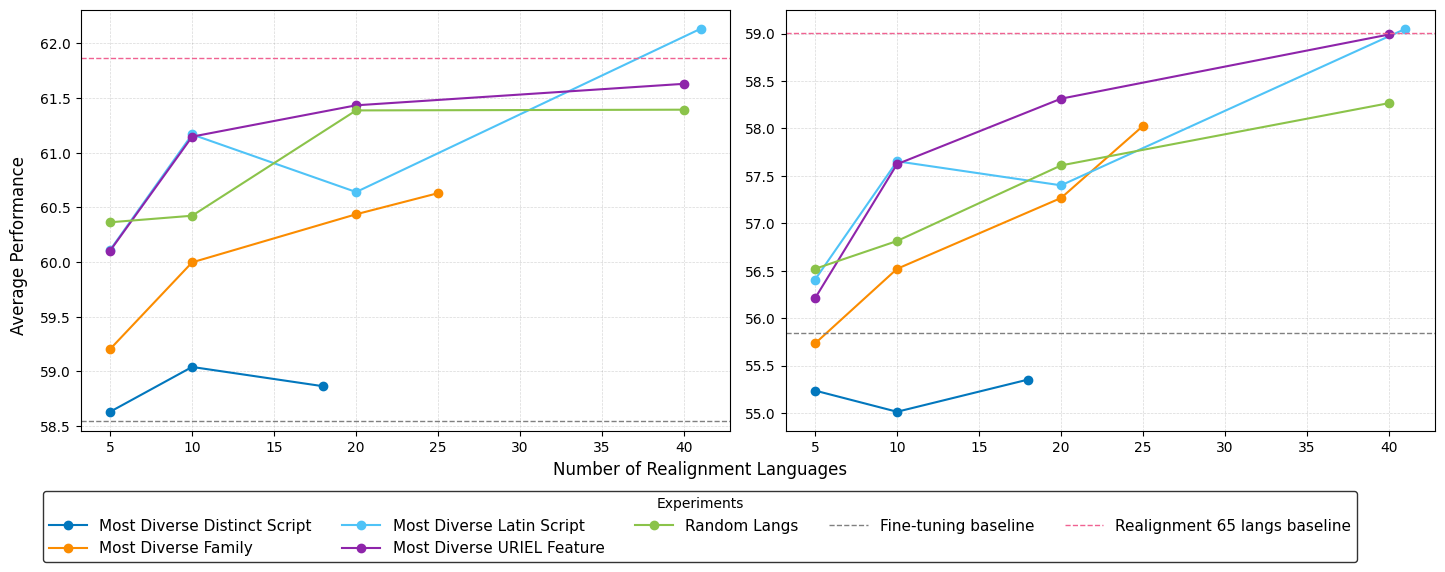

In [679]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

colors = [
    # "#FFB74D",  # light orange - Least Diverse Family
    # "#B3E5FC",  # light sky blue - Lease Diverse Same Script
    # "#CE93D8",  # light lavender-purple - Least Diverse URIEL
    "#0277BD",  # even deeper blue - Most Diverse Distinct Script
    "#FB8C00",  # deep orange - Most Diverse Family
    "#4FC3F7",  # medium sky blue - Most Diverse Same Script
    "#8E24AA",  # deep purple - Most Diverse URIEL Feature
    "#8BC34A",  # light green - Random
    # "#F06292",  # pink
    "#A1887F",  # taupe/brown
]
all_handles = []
for idx, (family_name, members) in enumerate(families.items()):
    # members = sorted(members, key=lambda x: int(x.split('_')[-1]))
    # if family_name == 'realignment_baseline':
    #     x = [21, 47, 65]
    # else:
    x = [int(name.split('_')[-1]) for name in members]
    y_xlmr = [xlmr_averaged_results[name] for name in members]
    y_mbert = [mbert_averaged_results[name] for name in members]
    
    color = colors[idx % len(colors)]
    label_base = beautify_exp_name(family_name, is_best=False)
    
    h1, = ax1.plot(x, y_xlmr, label=label_base, color=color, marker='o', linestyle='-')
    h2, = ax2.plot(x, y_mbert, label=label_base, color=color, marker='o', linestyle='-')
    all_handles.extend([h1])

# Plot horizontal reference lines with labels and save the handles
h_baseline_xlmr = ax1.axhline(
    y=xlmr_averaged_results['baseline'], color='gray',
    linestyle='dashed', linewidth=1, label='Fine-tuning baseline'
)
h_xtafri_xlmr = ax1.axhline(
    y=xlmr_averaged_results['xt_afri'], color='#F06292',
    linestyle='dashed', linewidth=1, label='Realignment 65 langs baseline'
)

h_baseline_mbert = ax2.axhline(
    y=mbert_averaged_results['baseline'], color='gray',
    linestyle='dashed', linewidth=1, label='Fine-tuning baseline'
)
h_xtafri_mbert = ax2.axhline(
    y=mbert_averaged_results['xt_afri'], color='#F06292',
    linestyle='dashed', linewidth=1, label='Realignment 65 langs baseline'
)
# plt.xlabel("Number of Realignment Languages")
# plt.ylabel("Average Performance")
fig.text(0.5, 0.04, 'Number of Realignment Languages', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'Average Performance', va='center', rotation='vertical', fontsize=12)
# Shared legend on the right
fig.legend(
    handles=all_handles + [h_baseline_xlmr, h_xtafri_xlmr],
    loc='lower center',
    ncol=5,  # or more depending on how many handles you have
    fontsize=11,
    frameon=True,
    edgecolor='black',
    handlelength=2.5,
    title="Experiments",
    bbox_to_anchor=(0.5, -0.15),  # Centered below the figure
)

# ax1.grid(True)
# ax2.grid(True)
for ax in [ax1, ax2]:
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
    ax.set_axisbelow(True)
# plt.tight_layout()
plt.tight_layout(rect=[0.05, 0.05, 1, 1])  # leaves space at bottom for legend
plt.savefig('incremental_line_graph.png', dpi=300, bbox_inches='tight')
# plt.show()

# Spider plot for AmericasNLI

In [474]:
import pandas as pd
import numpy as np
from collections import defaultdict

task = 'americasnli'

xlmr_americasnli_res = pd.read_csv(f"summary_xlm-roberta-base_{task}.csv")
# Extract accuracy before the "$\pm$"
language_cols = sorted(["final_eval_{}_accuracy".format(lang) for lang in NLI_DICT['AmericasNLI']] + ["final_eval_avg_performance"])
xlmr_americasnli_res = xlmr_americasnli_res[language_cols + ['exp']]
for col in language_cols:
    xlmr_americasnli_res[col] = xlmr_americasnli_res[col].str.split(' ').str[0].str.strip().astype(float)

mbert_americasnli_res = pd.read_csv(f"summary_bert-base-multilingual-cased_{task}.csv")
# Extract accuracy before the "$\pm$"
mbert_americasnli_res = mbert_americasnli_res[language_cols + ['exp']]
for col in language_cols:
    mbert_americasnli_res[col] = mbert_americasnli_res[col].str.split(' ').str[0].str.strip().astype(float)

xlmr_americasnli_res = xlmr_americasnli_res.set_index('exp')
mbert_americasnli_res = mbert_americasnli_res.set_index('exp')

In [476]:
mbert_americasnli_res.loc['least_family_en_10']

final_eval_avg_performance    41.47
final_eval_aym_accuracy       38.93
final_eval_bzd_accuracy       41.23
final_eval_cni_accuracy       42.87
final_eval_gn_accuracy        42.53
final_eval_hch_accuracy       39.00
final_eval_nah_accuracy       46.04
final_eval_oto_accuracy       42.25
final_eval_quy_accuracy       38.17
final_eval_shp_accuracy       44.93
final_eval_tar_accuracy       38.77
Name: least_family_en_10, dtype: float64

In [477]:
xlmr_best_mem = dict()
for i, exp_fam in enumerate(main_families):
    exp_candidates = [(exp_mem, xlmr_americasnli_res.loc[exp_mem]['final_eval_avg_performance']) for exp_mem in families[exp_fam]]
    exp_mem_best = max(exp_candidates, key=lambda x: x[1])
    xlmr_best_mem[exp_mem_best[0]] = exp_fam

In [478]:
xlmr_best_mem

{'least_family_en_20': 'least_family_en',
 'least_same_script_20': 'least_same_script',
 'least_uriel_en_20': 'least_uriel_en',
 'most_distinct_script_10': 'most_distinct_script',
 'most_family_en_20': 'most_family_en',
 'most_same_script_10': 'most_same_script',
 'most_uriel_en_40': 'most_uriel_en',
 'random_langs_with_seed_5': 'random_langs_with_seed',
 'xt_afri': 'xt_afri',
 'xt_only': 'xt_only',
 'afri_only': 'afri_only',
 'baseline': 'baseline'}

In [466]:
import re

families = defaultdict(list)
SORT_COLUMNS = sorted(set(xlmr_americasnli_res['exp']).intersection(set(mbert_americasnli_res['exp'])))

for name in SORT_COLUMNS:
    if 'abla' in name:
        continue
    else:
        # Remove trailing underscore + number
        match = re.match(r"(.+?)(?:_\d+)?$", name)
        if match:
            family = match.group(1)
            families[family].append(name)

baseline = ["xt_afri", "xt_only", "afri_only", "baseline"]
main_families = [family for family in sorted(families.keys()) if not (family.startswith("abla") or family in baseline)]
main_families = sorted(main_families) + baseline
main_families

['least_family_en',
 'least_same_script',
 'least_uriel_en',
 'most_distinct_script',
 'most_family_en',
 'most_same_script',
 'most_uriel_en',
 'random_langs_with_seed',
 'xt_afri',
 'xt_only',
 'afri_only',
 'baseline']